In [23]:
import numpy as np
import jax
import jax.numpy as jnp
from core.datasetclass import BenchmarkDataset

In [24]:
@jax.vmap
def transformation_jacobian(coords_elem) :
    x1, y1 = coords_elem[0]
    x2, y2 = coords_elem[1]
    x3, y3 = coords_elem[2]

    # Jacobian of shape function derivatives
    J = jnp.array([
        [x2 - x1, y2 - y1],
        [x3 - x1, y3 - y1]
    ])
    return J

In [25]:
@jax.vmap
def transformation_jacobian(coords_elem) :
    x1, y1 = coords_elem[0]
    x2, y2 = coords_elem[1]
    x3, y3 = coords_elem[2]

    # Jacobian of shape function derivatives
    J = jnp.array([
        [x2 - x1, y2 - y1],
        [x3 - x1, y3 - y1]
    ])
    return J

@jax.vmap
def deformation_gradient_element(coords_elem, disp_elem):
    x1, y1 = coords_elem[0]
    x2, y2 = coords_elem[1]
    x3, y3 = coords_elem[2]

    # Jacobian of shape function derivatives
    J = jnp.array([
        [x2 - x1, y2 - y1],
        [x3 - x1, y3 - y1]
    ])

    # Area factor
    detJ = jnp.linalg.det(J)

    # Shape function derivatives in reference space
    dN_ref = jnp.array([
        [-1., -1.],
        [ 1.,  0.],
        [ 0.,  1.]
    ])

    # Convert to physical derivatives: dN/dx = inv(J)^T * dN_ref
    dNdx = jnp.transpose(jnp.linalg.solve(J, dN_ref.T))

    # Gradient of displacement
    gradu = disp_elem.T @ dNdx  # 2x3 @ 3x2 = 2x2

    # Deformation gradient
    F = jnp.eye(2) + gradu
    return F, dNdx

In [62]:
dataset = BenchmarkDataset("dataset/benchmarks", "noise=low", "NeoHookean")

In [63]:
data = dataset[10]

/home/mmdiscovery/shared/core/datasetclass.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  output_nodes.ux[output_nodes.bcx!=0] = output_nodes.ux_orig[output_nodes.bcx!=0]
/home/mmdiscovery/shared/core/datasetclass.py:206: FutureWarnin

In [64]:
cells = data["cells"]
reaction_forces = jnp.array(data["reaction_forces"].to_numpy())

# Weak Form

$$f_i^a = \int P_{ij} \nabla_j N^a dV + \int t_i N^a_j dS$$ and $$\sum^{N_a}_{a=1} v_i^a f_i^a = 0$$

In [30]:
from core.utils import C_func, I1_func, I3_func

In [8]:
def NH_psi(F, mu = 1.0, kappa = 3.0) :
    if F.shape[-2:] == (2, 2) :
        F = jnp.array([[F[0, 0], F[0, 1], 0.], 
                       [F[1, 0], F[1, 1], 0.],
                       [0., 0., 1.]])
    C = C_func(F)
    I1 = I1_func(C)
    J = jnp.sqrt(I3_func(C))
    psi = mu/2 * (J**(-2/3) * I1 - 3) + kappa/2 * (J - 1)**2 
    return psi

P_nh = jax.vmap(jax.grad(NH_psi, 0))

In [ ]:
def NH_psi(F, params):
    mu, kappa = params
    if F.shape[-2:] == (2, 2):
        F = jnp.array([[F[0, 0], F[0, 1], 0.], 
                       [F[1, 0], F[1, 1], 0.],
                       [0.,      0.,     1. ]])

    C = C_func(F)
    I1 = I1_func(C)
    J  = jnp.sqrt(I3_func(C))

    psi = mu/2 * (J**(-2/3) * I1 - 3) + kappa/2 * (J - 1)**2
    return psi


P_nh = jax.vmap(jax.grad(NH_psi, argnums=0), in_axes=(0, None))
def physical_loss(params, coords, cells, u, reaction_forces, n_nodes, bc):
    mu, kappa = params

    # compute deformation gradient + shape function gradients
    F, dNdx = deformation_gradient_element(coords, u)
    dA = jnp.linalg.det(transformation_jacobian(coords)) / 2

    # compute 1st Piola stress
    piola = P_nh(F, params)    # shape (C, 2, 2)

    # element forces: (C, 2, 3)
    f_int_cell  = jnp.einsum("cij, cnj -> cin", piola, dNdx) * dA[:, None, None]
    f_int_cell  = jnp.swapaxes(f_int_cell, 1, 2)              # (C, 3, 2)

    # assemble into global vector

    f_int_nodes = jnp.zeros((n_nodes, 2)).at[cells].add(f_int_cell)

    # Dirichlet residual (only on free DOFs)
    blm_loss = jnp.sum(f_int_nodes[bc == 0] ** 2)

    # reaction matching loss
    reaction_ids = jnp.arange(1, 5)  # (4,)

    # reaction_mask[r, n, d] = 1 if bc[n,d] == r+1
    reaction_mask = (bc[None, :, :] == reaction_ids[:, None, None]).astype(f_int_nodes.dtype)
    # shape = (4, n_nodes, 2)

    # force for each reaction_id: sum over nodes & dofs
    f_react = jnp.sum(reaction_mask * f_int_nodes[None, :, :], axis=(1, 2))  # (4,)

    # target reactions must be JAX array
    r = jnp.asarray(reaction_forces).reshape(-1)  # (4,)

    reaction_loss = jnp.sum((f_react - r)**2)

    return blm_loss


In [69]:
(jnp.max(cells) + 1)

Array(1441, dtype=int64)

In [70]:
import optax

# trainable parameters
params = jnp.array([1.0, 1.0])   # initial guess [mu, kappa]

# choose optimizer
opt = optax.adam(1e-3)
opt_state = opt.init(params)
n_nodes = int(cells.max()) + 1
# JIT the loss and gradients
loss_and_grad = jax.jit(jax.value_and_grad(
    lambda params: physical_loss(params, data["coords_elems"], cells, data["disp_elems"], reaction_forces, n_nodes, data["bc"])
))


In [71]:

for step in range(50000):
    loss, grads = loss_and_grad(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    if step % 50 == 0:
        print(f"step {step:04d}  loss={loss:.6f}  mu={params[0]:.4f}, kappa={params[1]:.4f}")


step 0000  loss=0.000557  mu=0.9990, kappa=1.0010
step 0050  loss=0.000450  mu=0.9497, kappa=1.0503
step 0100  loss=0.000360  mu=0.9028, kappa=1.0970
step 0150  loss=0.000285  mu=0.8588, kappa=1.1409
step 0200  loss=0.000223  mu=0.8177, kappa=1.1816
step 0250  loss=0.000172  mu=0.7795, kappa=1.2193
step 0300  loss=0.000132  mu=0.7444, kappa=1.2538
step 0350  loss=0.000101  mu=0.7123, kappa=1.2850
step 0400  loss=0.000076  mu=0.6833, kappa=1.3131
step 0450  loss=0.000058  mu=0.6572, kappa=1.3380
step 0500  loss=0.000044  mu=0.6340, kappa=1.3597
step 0550  loss=0.000034  mu=0.6136, kappa=1.3785
step 0600  loss=0.000027  mu=0.5958, kappa=1.3943
step 0650  loss=0.000022  mu=0.5804, kappa=1.4075
step 0700  loss=0.000019  mu=0.5673, kappa=1.4183
step 0750  loss=0.000016  mu=0.5561, kappa=1.4267
step 0800  loss=0.000015  mu=0.5468, kappa=1.4332
step 0850  loss=0.000014  mu=0.5390, kappa=1.4378
step 0900  loss=0.000013  mu=0.5325, kappa=1.4410
step 0950  loss=0.000013  mu=0.5271, kappa=1.4428


In [21]:
def rbf(invariants, invariants_, variance=1.0, lengthscale=0.3):
    # z shape (..., d)
    invariants = invariants[:, None, :]
    invariants_ = invariants_[None, :, :]
    sq = jnp.sum((invariants - invariants_)**2, axis=-1)
    return variance * jnp.exp(-0.5 * sq / (lengthscale**2))

Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.], dtype=float64)

In [ ]:
def H_matrix() :
    H_ret = jnp.zeros((n_res, 3))

    H_ret = H_ret.at[i, k].add()

    return H_ret

In [ ]:
for i in range(n_res) :
    for a in range(0, 2) :
        for b in range(0, 2) :
            H[i, 0] = (2 * F[a, b] * dNdX[i, a]) * w[i]
            H[i, 1] = (2 * (I1[i] * F[a, b] - (F @ C)[a,b])) * w[i]
            H[i, 2] = (2 * I3[i] * inv(F.T)[a, b]) * w[i]

In [ ]:
# jax_fem_gp_hyperelastic_2d.py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# -----------------------------
# 1. Toy 2D displacement field
# -----------------------------
def displacement_field(xy):
    """Simple 2D displacement: u_x = x^2, u_y = y^2"""
    x, y = xy
    u_x = x**2
    u_y = y**2
    return jnp.array([u_x, u_y])

# Quadrature points (1-point for simplicity)
quad_points = jnp.array([[0.5, 0.5]])
weights = jnp.array([1.0])
Q = quad_points.shape[0]

# -----------------------------
# 2. Compute deformation gradient F at quadrature points
# -----------------------------
def deformation_gradient(u_fn, xy):
    """Compute F = I + grad u (Jacobian)"""
    def u_flat(xy_flat):
        return u_fn(xy_flat)
    grad_u = jax.jacfwd(u_flat)(xy)
    F = jnp.eye(2) + grad_u
    return F

F_q = jnp.stack([deformation_gradient(displacement_field, qp) for qp in quad_points])  # (Q,2,2)

# -----------------------------
# 3. Compute invariants and derivatives
# -----------------------------
def invariants_and_derivatives(F):
    C = F.T @ F
    I1 = jnp.trace(C)
    I2 = 0.5 * (I1**2 - jnp.trace(C @ C))
    I3 = jnp.linalg.det(C)
    # derivatives wrt F (2x2)
    dI1_dF = 2*F
    dI2_dF = 2*(I1*F - F @ C)
    dI3_dF = 2*jnp.linalg.det(F)**2 * jnp.linalg.inv(F).T
    dI_dF = jnp.stack([dI1_dF, dI2_dF, dI3_dF])  # (3,2,2)
    return jnp.array([I1, I2, I3]), dI_dF

inv_list = [invariants_and_derivatives(F_q[q]) for q in range(Q)]
I_q = jnp.stack([x[0] for x in inv_list])         # (Q,3)
dI_dF_q = jnp.stack([x[1] for x in inv_list])     # (Q,3,2,2)

# -----------------------------
# 4. FE basis gradients (toy)
# -----------------------------
n_res = 10  # residuals = 4 nodes of quad element
grad_phi = jnp.ones((n_res, Q, 2))  # shape (n_res,Q,dim) for toy example

# -----------------------------
# 5. Build H
# -----------------------------
def build_H(weights, grad_phi, dI_dF_q):
    n_res, Q, dim = grad_phi.shape
    H = jnp.zeros((n_res, 3*Q))
    for i in range(n_res):
        for q in range(Q):
            for k in range(3):
                # contraction P : grad_phi
                H = H.at[i, 3*q + k].set(weights[q] * jnp.sum(dI_dF_q[q,k] * grad_phi[i,q,:]))
    return H

H = build_H(weights, grad_phi, dI_dF_q)

# -----------------------------
# 6. GP kernel and derivatives (RBF)
# -----------------------------
def rbf_kernel(x1, x2, variance=1.0, lengthscale=1.0):
    x1 = x1[:, None, :]
    x2 = x2[None, :, :]
    d2 = jnp.sum((x1 - x2)**2, axis=2)
    return variance * jnp.exp(-0.5*d2 / lengthscale**2)

# Prior covariance of Psi
K_ZZ = rbf_kernel(I_q, I_q)

# Derivative covariances
def kernel_derivatives(I_q, lengthscale=1.0, variance=1.0):
    Q = I_q.shape[0]
    K_der = jnp.zeros((3*Q, 3*Q))
    K_cross = jnp.zeros((Q, 3*Q))
    for p in range(Q):
        for q in range(Q):
            z_p = I_q[p]
            z_q = I_q[q]
            k_pq = variance * jnp.exp(-0.5 * jnp.sum((z_p - z_q)**2)/lengthscale**2)
            diff = (z_p - z_q)/lengthscale**2
            # second derivatives for K_der
            for k in range(3):
                for l in range(3):
                    K_der = K_der.at[3*p+k, 3*q+l].add(k_pq * (diff[k]*diff[l]))
                K_cross = K_cross.at[p, 3*q + k].add(-k_pq * diff[k])
    return K_der, K_cross

K_der, K_cross = kernel_derivatives(I_q)

# -----------------------------
# 7. Condition GP on residual R = 0
# -----------------------------
sigma = 1e-6
S = H @ K_der @ H.T + sigma**2 * jnp.eye(n_res)
mu_post = K_cross @ H.T @ jnp.linalg.solve(S, jnp.zeros(n_res))
Sigma_post = K_ZZ - K_cross @ H.T @ jnp.linalg.solve(S, H @ K_cross.T)

# -----------------------------
# 8. Plot posterior mean and CI
# -----------------------------
x_vals = jnp.arange(Q)
plt.figure()
plt.plot(x_vals, mu_post, 'b-', label='Posterior mean Psi')
plt.fill_between(x_vals,
                 mu_post - 2*jnp.sqrt(jnp.diag(Sigma_post)),
                 mu_post + 2*jnp.sqrt(jnp.diag(Sigma_post)),
                 color='blue', alpha=0.3, label='Confidence')
plt.xlabel("Quadrature point")
plt.ylabel("Psi")
plt.legend()
plt.show()


TypeError: dot_general requires contracting dimensions to have the same shape, got (1,) and (3,).

In [28]:
H

Array([[ 8., 32., 32.],
       [ 8., 32., 32.],
       [ 8., 32., 32.],
       [ 8., 32., 32.],
       [ 8., 32., 32.],
       [ 8., 32., 32.],
       [ 8., 32., 32.],
       [ 8., 32., 32.],
       [ 8., 32., 32.],
       [ 8., 32., 32.]], dtype=float64)

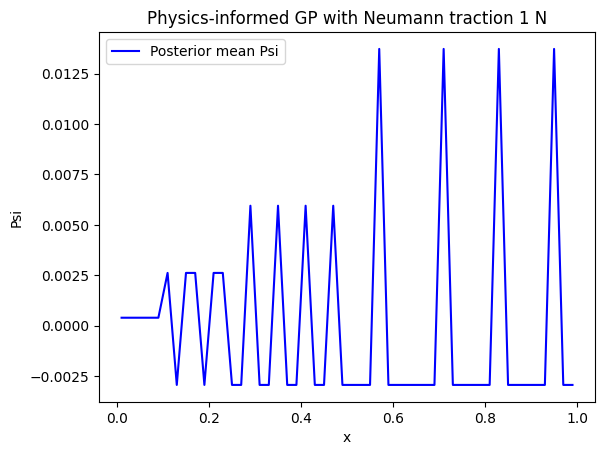

In [67]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# -----------------------------
# 1. 1D FEM mesh
# -----------------------------
N = 50
x_nodes = jnp.linspace(0, 1, N+1)
h = x_nodes[1] - x_nodes[0]

# Displacement field (toy)
def u_field(x):
    return (2 - 1)/4 * x

u_nodes = u_field(x_nodes)

# Compute F at midpoints
x_mid = 0.5*(x_nodes[:-1] + x_nodes[1:])
F_mid = 1.0 + (u_nodes[1:] - u_nodes[:-1])/h
Q = len(F_mid)

# -----------------------------
# 2. Invariants and derivatives (1D toy)
# -----------------------------
I_q = F_mid**2
dI_dF_q = 2*F_mid  # dI/dF

# -----------------------------
# 3. FEM basis gradients (P1)
# -----------------------------
grad_phi = jnp.ones((N-1, Q))  # toy simplification
weights = jnp.ones(Q) * h

# -----------------------------
# 4. Build H
# -----------------------------
H = jnp.zeros((N-1, Q))
for i in range(N-1):
    for q in range(Q):
        H = H.at[i,q].set(weights[q] * dI_dF_q[q] * grad_phi[i,q])

# -----------------------------
# 5. GP kernel and derivatives
# -----------------------------
lengthscale = 1.0
variance = 1.0
def rbf_kernel(x1, x2, variance=1.0, lengthscale=0.2):
    x1 = x1[:, None]
    x2 = x2[None, :]
    d2 = (x1 - x2)**2
    return variance * jnp.exp(-0.5*d2/lengthscale**2)

K_ZZ = rbf_kernel(I_q, I_q, variance,lengthscale)

# Toy derivatives
K_der = jnp.zeros((Q,Q))
K_cross = jnp.zeros((Q,Q))
for p in range(Q):
    for q in range(Q):
        k_pq = jnp.exp(-0.5*(I_q[p]-I_q[q])**2/lengthscale**2)
        diff = (I_q[p]-I_q[q])/lengthscale**2
        K_der = K_der.at[p,q].add(k_pq * diff*diff)
        K_cross = K_cross.at[p,q].add(-k_pq * diff)

# -----------------------------
# 6. Neumann BC: traction 1 N at right end
# -----------------------------
f_ext = jnp.zeros(N-1)
f_ext = f_ext.at[-1].set(2.0)  # apply traction to last interior node

# -----------------------------
# 7. Condition GP on residual
# -----------------------------
sigma = 1e-6
S = H @ K_der @ H.T + sigma**2 * jnp.eye(N-1)
mu_post = K_cross @ H.T @ jnp.linalg.solve(S, f_ext)
Sigma_post = K_ZZ - K_cross @ H.T @ jnp.linalg.solve(S, H @ K_cross.T)

# -----------------------------
# 8. Plot posterior mean and confidence
# -----------------------------
plt.figure()
plt.plot(x_mid, mu_post, 'b-', label='Posterior mean Psi')
# plt.fill_between(x_mid,
#                  mu_post - 2*jnp.sqrt(jnp.diag(Sigma_post)),
#                  mu_post + 2*jnp.sqrt(jnp.diag(Sigma_post)),
#                  color='blue', alpha=0.3, label='Confidence')
plt.xlabel("x")
plt.ylabel("Psi")
plt.title("Physics-informed GP with Neumann traction 1 N")
plt.legend()
plt.show()


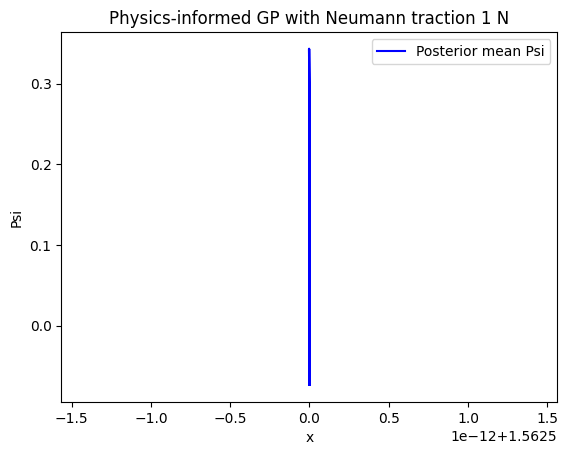

In [61]:
plt.figure()
plt.plot(I_q, mu_post, 'b-', label='Posterior mean Psi')
# plt.fill_between(x_mid,
#                  mu_post - 2*jnp.sqrt(jnp.diag(Sigma_post)),
#                  mu_post + 2*jnp.sqrt(jnp.diag(Sigma_post)),
#                  color='blue', alpha=0.3, label='Confidence')
plt.xlabel("x")
plt.ylabel("Psi")
plt.title("Physics-informed GP with Neumann traction 1 N")
plt.legend()
plt.show()

In [62]:
I_q

Array([1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625,
       1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625,
       1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625,
       1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625,
       1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625,
       1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625, 1.5625,
       1.5625, 1.5625], dtype=float64)

In [1]:
import jax 
import jax.numpy as jnp
from core.datasetclass import TractionDataset
from core.utils import * 

/dolfinx-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = TractionDataset("dataset","NH")
data = dataset[1]

In [3]:
coords = data["mesh_pos"][:,:2]
cells = data["cells"]
u = data["u"]
node_type = data["node_type"]
load_parameter = data["load_parameter"]

In [4]:
coord_cells = coords[cells]
u_cells = u[cells]

In [5]:
from core.material_models import get_material

In [6]:
@jax.vmap
def fto3x3(f) :
    f3x3 = jnp.array([[f[0,0], f[0,1], 0.0],
                      [f[1,0], f[1,1], 0.0],
                      [0.0, 0.0, 1.0]])
    return f3x3

In [7]:

def MR_psi(F: jnp.ndarray, params = jnp.array([0.1, 0.1, 0.1, 0.1,0.1, 0.1,0.1, 0.1,0.1, 0.1])) -> jnp.ndarray:
    dev_params = params[:-2]
    vol_params = params[-2:]
    if F.shape[-2:] == (2, 2):
        F = jnp.array([[F[0, 0], F[0, 1], 0.], 
                    [F[1, 0], F[1, 1], 0.],
                    [0.,      0.,     1. ]])
    c = C_func(F)
    I1 = I1_func(c)
    I2 = I2_func(c)
    I3 = I3_func(c)
    I3_safe = jnp.clip(I3, 1.0e-8, 1.0e8)
    i1_dev = I3_safe**(-1/3) * I1
    i2_dev = I3_safe**(-2/3) * I2

    X = i1_dev - 3.0
    Y = i2_dev - 3.0
    
    # --- Deviatoric Terms (W) ---
    # Assuming dev_params = [c01, c02, c10, c11, c12, c20, c21, c22]
    # Using the standard N=2 Polynomial Model terms (C10, C01, C20, C11, C02)
    dev_terms = (
        # C10 * X
        dev_params[2] * X + 
        # C01 * Y
        dev_params[0] * Y + 
        # C20 * X**2
        dev_params[5] * X**2 + 
        # C11 * X * Y
        dev_params[3] * X * Y + 
        # C02 * Y**2
        dev_params[1] * Y**2 +

        dev_params[4] * X*Y**2 + 

        dev_params[6] * X**2 * Y + 

        dev_params[7] * X**2 * Y ** 2

        # Add C12, C21, C22 terms here if required by your specific model definition
    )
    
    # --- Volumetric Terms (U) ---
    # Assuming vol_params = [d0, d1] are D2 and D1 parameters (inverse bulk moduli)
    J = jnp.sqrt(I3_safe)
    J_minus_1 = J - 1.0

    # Assuming the volumetric function U(J) = (1/D1)(J-1)^2 + (1/D2)(J-1)^4
    # with D1=d1 and D2=d0 (or vice versa, depending on convention)
    
    # D1 is typically the lower order term (quadratic, hence d1)
    # D2 is typically the higher order term (quartic, hence d0)
    vol_terms = (
        # (1/D1) * (J - 1)**2
        (vol_params[0]) * J_minus_1**2
        # (1/D2) * (J - 1)**4
    )
    
    return dev_terms + vol_terms

In [8]:
def NH_psi(F, params = jnp.array([0.1, 0.1])):
    mu, kappa = params
    if F.shape[-2:] == (2, 2):
        F = jnp.array([[F[0, 0], F[0, 1], 0.], 
                       [F[1, 0], F[1, 1], 0.],
                       [0.,      0.,     1. ]])

    C = C_func(F)
    I1 = I1_func(C)
    I2 = I2_func(C)
    J  = jnp.sqrt(I3_func(C))

    psi = mu/2 * (J**(-2/3) * I1 - 3) + kappa/2 * (J - 1)**2
    # psi = mu/2 * (J**(-2/3) * I1 - 3) + c1 * (J**(-2/3) * I1 - 3)**2 + c2 * (J**(-4/3) * I2 - 3) + kappa/2 * (J - 1)**2
    return psi


P_nh = jax.vmap(jax.grad(NH_psi, argnums=0), in_axes=(0))


In [9]:
F, dNdx = deformation_gradient_element(coord_cells, u_cells)

In [10]:
P_nh(F)

Array([[[ 3.93341925e-02, -1.46049266e-04],
        [-1.79278044e-04,  6.29620017e-02]],

       [[ 3.96063463e-02, -6.80538795e-05],
        [-1.47673451e-04,  6.30619383e-02]],

       [[ 3.97471776e-02, -2.56148650e-04],
        [-3.60978816e-04,  6.32394279e-02]],

       ...,

       [[ 2.82326510e-02, -9.02639525e-04],
        [-6.55355987e-04,  7.21062491e-02]],

       [[ 2.76913755e-02, -3.40867121e-04],
        [-1.63992863e-04,  7.19562815e-02]],

       [[ 2.73395438e-02, -4.58804416e-04],
        [-3.89560014e-04,  7.14905309e-02]]], dtype=float64)

In [11]:
fto3x3(F)

Array([[[ 1.07516534e+00, -9.90122656e-04,  0.00000000e+00],
        [-1.75333520e-03,  1.27441667e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 1.07615546e+00,  0.00000000e+00,  0.00000000e+00],
        [-1.82282207e-03,  1.27434718e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 1.07632599e+00, -1.41494849e-03,  0.00000000e+00],
        [-3.80853746e-03,  1.27516893e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       ...,

       [[ 1.00346842e+00, -9.44757427e-03,  0.00000000e+00],
        [-3.59626258e-03,  1.37078659e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 1.00174567e+00, -4.21163661e-03,  0.00000000e+00],
        [ 0.00000000e+00,  1.37101181e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 1.00160384e+00, -4.35345990e-03,  0.00000000e+00],
 

In [12]:
P_mr = jax.vmap(jax.grad(MR_psi, argnums=0), in_axes=(0, None))

In [13]:
piola = P_mr(F, params) 

NameError: name 'params' is not defined

In [14]:
import jax
import jax.numpy as jnp
# helper: per-element edge-based neumann traction contribution
def _neumann_cell_force(coords_el, types_el, t3, t4):
    """
    coords_el: (3,2) float - coordinates of the 3 nodes of the element
    types_el:  (3,) int - node_type for these 3 nodes (global node_type[cells])
    t3, t4: scalars - traction magnitudes for types 3 and 4
    returns: (3,2) local nodal traction vector for this element
    """
    edges = jnp.array([[0, 1],
                       [1, 2],
                       [2, 0]])  # three local edges
    f_cell = jnp.zeros((3, 2))

    def body_fun(idx, f):
        i = edges[idx, 0]
        j = edges[idx, 1]

        ti = types_el[i]
        tj = types_el[j]

        # Only apply traction if both nodes of the edge have the same neumann type.
        is_right = (ti == 3) & (tj == 3)
        is_top   = (ti == 4) & (tj == 4)

        # choose traction vector for edge
        t_edge = jnp.where(is_right, jnp.array([t3, 0.0]),
                 jnp.where(is_top,   jnp.array([0.0, t4]),
                                         jnp.array([0.0, 0.0])))

        xi = coords_el[i]
        xj = coords_el[j]
        L = jnp.linalg.norm(xj - xi)

        # nodal contribution from this edge: each edge contributes L/2 * T to each of its two nodes
        fe_local = 0.5 * L * t_edge  # shape (2,)

        f = f.at[i].add(fe_local)
        f = f.at[j].add(fe_local)
        return f

    f_cell = jax.lax.fori_loop(0, 3, body_fun, f_cell)
    return f_cell  # (3,2)


def physical_loss(params, coords, cells, u,
                  n_nodes, node_type):
    """
    params: (mu, kappa)
    coords: (C, 3, 2) per-element nodal coords
    cells:  (C, 3) global node indices per element
    u: displacement (format compatible with deformation_gradient_element)
    reaction_forces: target reaction vector (4,) or similar used previously
    n_nodes: total number of nodes
    bc: (n_nodes, 2) boundary code mask (0 free, 1..4 etc)
    node_type: (n_nodes, 1) ints: 0 free, 1/2 fixed (dirichlet), 3 right, 4 top
    load_parameter: (2,) or (2,1) - [t3, t4]
    """

    # --- INTERNAL FORCES (unchanged) ---
    F, dNdx = deformation_gradient_element(coords, u)   # (C,2,2), (C,3,2,2?) matches your API
    dA = jnp.linalg.det(transformation_jacobian(coords)) / 2  # (C,)
    f = fto3x3(F)
    p_pos = jnp.exp(params)
    piola = P_mr(f, p_pos)[:, :2, :2]   # (C,2,2)

    # internal element nodal forces: (C,3,2)
    f_int_cell = jnp.einsum("cij, cnj -> cin", piola, dNdx) * dA[:, None, None]
    f_int_cell = jnp.swapaxes(f_int_cell, 1, 2)    # (C,3,2)

    # assemble into global internal force vector (n_nodes, 2)
    f_int_nodes = jnp.zeros((n_nodes, 2)).at[cells].add(f_int_cell)

    # --- NEUMANN EDGE-LENGTH TRACTION ---
    # normalize load_parameter to flat array
    lp = jnp.asarray(load_parameter).reshape(-1)
    t3 = 1.3
    t4 = 1.3 * 1.1
    # node_type may be (n_nodes,1) so flatten
    node_type_flat = jnp.asarray(node_type).reshape(-1)  # (n_nodes,)
    types_per_cell = node_type_flat[cells]               # (C,3)

    # vectorize per-element traction computation
    per_cell_vmap = jax.vmap(_neumann_cell_force, in_axes=(0, 0, None, None))
    f_neu_cells = per_cell_vmap(coords, types_per_cell, t3, t4)  # (C,3,2)

    # assemble global neumann nodal forces
    f_neu_nodes = jnp.zeros((n_nodes, 2)).at[cells].add(f_neu_cells)

    # --- Residual R = int(grad v : P) dx  -  int(v·T) ds(Neumann)
    R_nodes = f_int_nodes - f_neu_nodes

    # only free DOFs contribute to the residual loss (bc == 0)
    blm_loss = jnp.sum(R_nodes[(node_type != 1) & (node_type != 2)] ** 2)

    fixed_nodes_loss1 = jnp.sum((jnp.sum(R_nodes[node_type == 1], axis = 0) + jnp.sum(f_neu_nodes[node_type == 3], axis = 0))**2)
    fixed_nodes_loss2 = jnp.sum((jnp.sum(R_nodes[node_type == 2], axis = 0) + jnp.sum(f_neu_nodes[node_type == 4], axis = 0))**2)
    # --- Reaction matching (unchanged)
    # reaction_ids = jnp.arange(1, 5)  # 1..4
    # reaction_mask = (bc[None, :, :] == reaction_ids[:, None, None]).astype(f_int_nodes.dtype)
    # f_react = jnp.sum(reaction_mask * f_int_nodes[None, :, :], axis=(1, 2))
    # r = jnp.asarray(reaction_forces).reshape(-1)
    # reaction_loss = jnp.sum((f_react - r) ** 2)

    return blm_loss + fixed_nodes_loss1 + fixed_nodes_loss2, f_int_nodes, f_neu_nodes, R_nodes


In [15]:
load_parameter

array(1.3)

In [16]:
params = jnp.array([0.1, 0.1, 0.1, 0.1,0.1, 0.1,0.1, 0.1,0.1, 0.1])   # initial guess [mu, kappa]

In [17]:
_, f_int_nodes, f_neumann_nodes, r_nodes = physical_loss(params, coord_cells, cells, u_cells, coords.shape[0], node_type)

In [18]:
print(_)

174575.60522711984


In [19]:
loss_and_grad = jax.jit(jax.value_and_grad(
    lambda params: physical_loss(params, coord_cells, cells, u_cells, coords.shape[0], node_type)[0]
))

In [20]:
optimizer = optax.lbfgs(max_state=50, learning_rate=1e-1)

NameError: name 'optax' is not defined

In [38]:
@jax.jit
def step(params, opt_state):
    """
    Performs one optimization step (forward pass, gradient calculation, and parameter update).
    """
    # 1. Compute loss and gradients
    # This uses the loss_and_grad function you already defined
    loss_value, grads = loss_and_grad(params)

    # 2. Get updates from the optimizer
    updates, opt_state = opt.update(grads, opt_state, params)

    # 3. Apply updates to the parameters
    new_params = optax.apply_updates(params, updates)

    return new_params, opt_state, loss_value

In [21]:
params = jnp.array([0.1, 0.1, 0.1, 0.1,0.1, 0.1,0.1, 0.1,0.1]) 

In [22]:
# Assuming you have defined these variables from your context:
# coord_cells, cells, u_cells, node_type
num_coords = coords.shape[0] # Renamed from coords.shape[0] to match the function signature

num_steps = 100 # Choose a suitable number of steps
log_freq = 1

print(f"Starting optimization with {num_steps} steps...")

for i in range(1, num_steps + 1):
    # Perform a single optimization step
    params, opt_state, loss = step(
        params,
        opt_state,
    )

    # Log results
    if i % log_freq == 0 or i == 1:
        # Note: .item() forces a device-to-host transfer, which should be avoided in
        # performance-critical inner loops, but is fine for logging.
        print(f"Step {i:4d}/{num_steps} | Loss: {loss.item():.6e}")

# --- Final Results ---
print("\nOptimization Finished.")
print(f"Final Loss: {loss.item():.6e}")
print("Final Parameters (first 5 elements):")
print(jnp.exp(params))

Starting optimization with 100 steps...


NameError: name 'step' is not defined

In [56]:
import optax

# trainable parameters
params = jnp.array([0.1, 0.1, 0.1, 0.1,0.1, 0.1,0.1, 0.1,0.1])   # initial guess [mu, kappa]

# choose optimizer
# opt = optax.lbfgs(1e-3)
opt = optax.adam(1e-1)
opt_state = opt.init(params)
n_nodes = int(cells.max()) + 1
# JIT the loss and gradients
loss_and_grad = jax.jit(jax.value_and_grad(
    lambda params: physical_loss(params, coord_cells, cells, u_cells, coords.shape[0], node_type)[0]
))


for step in range(50000):
    loss, grads = loss_and_grad(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    if step % 50 == 0:
        print(f"step {step:04d}  loss={loss:.6f} {jnp.exp(params)}")



step 0000  loss=174575.605227 [1.         1.         1.         1.         1.         1.
 1.         1.22140276 1.10517092]
step 0050  loss=2519.363730 [0.13116974 0.13353182 0.1290071  0.13325643 0.13364442 0.1328424
 0.13351926 7.07635514 1.10517092]
step 0100  loss=1319.347007 [0.09456373 0.09741674 0.09200431 0.09707913 0.09754866 0.09657325
 0.09739476 6.57520909 1.10517092]
step 0150  loss=851.367083 [0.07577545 0.07855628 0.07330685 0.07822371 0.07867986 0.07772635
 0.07852792 5.63235397 1.10517092]
step 0200  loss=600.357017 [0.06360693 0.06618795 0.061327   0.06587682 0.06629761 0.065412
 0.06615522 5.00967114 1.10517092]
step 0250  loss=449.447581 [0.05507173 0.05744187 0.0529823  0.05715429 0.05753777 0.05672491
 0.05740598 4.57574907 1.10517092]
step 0300  loss=351.072277 [0.04873421 0.05091069 0.04681614 0.05064509 0.05099425 0.05024869
 0.05087238 4.25279578 1.10517092]
step 0350  loss=283.004030 [0.04382627 0.04583126 0.042058   0.04558532 0.04590403 0.04521831
 0.045791

In [21]:
loss_and_grad(params)

(Array(174575.60522712, dtype=float64),
 Array([  763.5768888 ,  5957.35747161,   638.64948908,  6225.73531257,
        39041.84241003,  6366.4277298 , 44205.18198814,  -124.9943524 ,
            0.        ], dtype=float64))

In [62]:
opt = optax.lbfgs(
    learning_rate=5.0,   # usually 1.0 for LBFGS
    memory_size=10,      # history size
)
params = jnp.array([0.1, 0.1, 0.1, 0.1,0.1, 0.1,0.1, 0.1,0.1])   # initial guess [mu, kappa]
opt_state = opt.init(params)
max_iters = 500  # LBFGS converges much faster than Adam
loss_func = jax.jit(lambda params: physical_loss(params, coord_cells, cells, u_cells, coords.shape[0], node_type)[0])
loss_and_grad = jax.jit(jax.value_and_grad(
    lambda params: physical_loss(params, coord_cells, cells, u_cells, coords.shape[0], node_type)[0]
))

for step in range(max_iters):
    value, grad = loss_and_grad(params)

    updates, opt_state = opt.update(
        grad,
        opt_state,
        params,
        value=value,
        grad=grad,
        value_fn=loss_func
    )

    params = optax.apply_updates(params, updates)

    if step % 1 == 0:
        print(f"step {step:04d}  loss={value:.6f}  params={jnp.exp(params)}")

    # # Optional convergence check
    # if opt_state.converged:
    #     print("LBFGS converged")
    #     break


step 0000  loss=174575.605227  params=[1.03698435 0.67243474 1.04784526 0.65755082 0.04259012 0.64988027
 0.02768786 1.11675222 1.10517092]
step 0001  loss=647.895797  params=[1.0156471  0.61152706 1.0284745  0.59630552 0.04097148 0.58806865
 0.02690234 1.11858357 1.10517092]
step 0002  loss=568.097972  params=[0.40038381 0.03685159 0.4434517  0.03502045 0.01128994 0.03396806
 0.0110571  1.22259428 1.10517092]
step 0003  loss=24.996540  params=[0.29706612 0.02884504 0.33619643 0.02752697 0.00954707 0.0267943
 0.00945915 1.41854178 1.10517092]
step 0004  loss=16.637953  params=[0.15340546 0.01502026 0.17816363 0.01442459 0.00603077 0.01411728
 0.00603658 2.83271878 1.10517092]
step 0005  loss=6.230329  params=[0.02653509 0.00377766 0.02984489 0.00366674 0.00206945 0.00359731
 0.00200529 0.21621085 1.10517092]
step 0006  loss=3.229199  params=[0.07354421 0.00677336 0.09328263 0.00664667 0.00311678 0.00669219
 0.00323903 1.68601435 1.10517092]
step 0007  loss=1.171738  params=[0.07559485 

KeyboardInterrupt: 

In [63]:
grad

Array([3.24853313e-15, 2.41848785e-21, 1.23038855e-08, 2.71909499e-21,
       3.36428744e-27, 2.87149204e-21, 2.48692152e-28, 2.19331969e-07,
       0.00000000e+00], dtype=float64)

In [25]:
grads

Array([1.37643114e-09, 2.31190656e-09, 1.85592830e-10, 2.35374690e-09,
       6.49144676e-09, 2.37447317e-09, 7.07329040e-09, 6.97903769e-10,
       0.00000000e+00], dtype=float64)

In [25]:

for step in range(5000*2*2*2):
    loss, grads = loss_and_grad(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    if step % 50 == 0:
        print(f"step {step:04d}  loss={loss:.6f} {jnp.exp(params)}")


step 0000  loss=143845.749656 [1.00238464 1.00238474 1.00238432 1.00238469 1.0023846  1.00238462
 1.00238457 1.22265789 1.10517092]
step 0050  loss=131415.553939 [0.95819443 0.95819508 0.95819331 0.95819493 0.95819477 0.95819468
 0.95819469 1.28549973 1.10517092]
step 0100  loss=120533.635253 [0.91775829 0.91776017 0.91775562 0.91775981 0.91775966 0.91775925
 0.91775947 1.35178427 1.10517092]
step 0150  loss=110950.868914 [0.88060914 0.88061316 0.88060401 0.88061249 0.88061245 0.88061144
 0.88061211 1.42179273 1.10517092]
step 0200  loss=102466.378264 [0.846354   0.84636124 0.84634535 0.84636011 0.84636034 0.84635838
 0.84635979 1.49582708 1.10517092]
step 0250  loss=94916.747579 [0.81465986 0.81467154 0.81464649 0.81466982 0.8146705  0.81466718
 0.81466967 1.57421212 1.10517092]
step 0300  loss=88167.945798 [0.78524275 0.78526023 0.78522337 0.78525775 0.78525909 0.78525397
 0.78525791 1.6572975  1.10517092]
step 0350  loss=82109.209400 [0.75785907 0.75788383 0.75783227 0.75788043 0.75

In [26]:
params

Array([ -9.17220475, -10.3874806 ,  -0.65999323, -10.34241358,
       -10.42296003, -10.26842128, -10.40368627,   0.39656732,
         0.1       ], dtype=float64)

In [47]:
(node_type == 3).sum()

np.int64(20)

In [284]:
@jax.vmap
def fto3x3(f) :
    f3x3 = jnp.array([[f[0,0], f[0,1], 0.0],
                      [f[1,0], f[1,1], 0.0],
                      [0.0, 0.0, 1.0]])
    return f3x3
@jax.vmap
def q_stress(f) :
    c = f.T @ f
    i1 = jnp.trace(c)
    i2 = 0.5 * (jnp.trace(c) ** 2 - jnp.trace(c @ c))
    i3 = jnp.linalg.det(c)
    return i3 ** (-1/3) * (f - 1/3 * i1 * jnp.linalg.inv(f.T))
@jax.vmap
def r_stress(f) :
    j = jnp.linalg.det(f)
    return j * (j - 1) *jnp.linalg.inv(f.T)

In [300]:
F, dNdx = deformation_gradient_element(coord_cells, u_cells)
dA = jnp.linalg.det(transformation_jacobian(coord_cells)) / 2

In [301]:
f3x3 = fto3x3(F)

In [302]:
f3x3

Array([[[ 1.07516534e+00, -9.90122656e-04,  0.00000000e+00],
        [-1.75333520e-03,  1.27441667e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 1.07615546e+00,  0.00000000e+00,  0.00000000e+00],
        [-1.82282207e-03,  1.27434718e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 1.07632599e+00, -1.41494849e-03,  0.00000000e+00],
        [-3.80853746e-03,  1.27516893e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       ...,

       [[ 1.00346842e+00, -9.44757427e-03,  0.00000000e+00],
        [-3.59626258e-03,  1.37078659e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 1.00174567e+00, -4.21163661e-03,  0.00000000e+00],
        [ 0.00000000e+00,  1.37101181e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 1.00160384e+00, -4.35345990e-03,  0.00000000e+00],
 

In [326]:
q = q_stress(f3x3)[:, :2, :2]
r = r_stress(f3x3)[:, :2, :2]

In [327]:
dNdx.shape

(960, 3, 2)

In [328]:
Fq_cai = jnp.einsum("cij, caj -> cai", q, dNdx) * dA[:, None, None] 

In [329]:
Fr_cai = jnp.einsum("cij, caj -> cai", r, dNdx)* dA[:, None, None]

In [330]:
Fq_glob = jnp.zeros((n_nodes, 2))
Fr_glob = jnp.zeros((n_nodes, 2))

In [331]:
cells

array([[  0,   1,   2],
       [  3,   1,   0],
       [  2,   1,   4],
       ...,
       [514, 518, 519],
       [520, 518, 515],
       [519, 518, 520]], shape=(960, 3), dtype=int32)

In [332]:
Fq_glob = Fq_glob.at[cells].add(Fq_cai)
Fr_glob = Fr_glob.at[cells].add(Fr_cai)

In [339]:
per_cell_vmap = jax.vmap(_neumann_cell_force, in_axes=(0, 0, None, None))
f_neu_cells = per_cell_vmap(coord_cells, node_type[cells], 1.3, 1.3*1.1)  # (C,3,2)
f_neu_nodes = jnp.zeros((n_nodes, 2)).at[cells].add(f_neu_cells)

In [340]:
f_neu_nodes

Array([[0.     , 0.03575],
       [0.     , 0.     ],
       [0.     , 0.0715 ],
       ...,
       [0.     , 0.     ],
       [0.065  , 0.     ],
       [0.0325 , 0.     ]], dtype=float64)

In [355]:
Fq_glob_stacked = Fq_glob.reshape(-1)
Fr_glob_stacked = Fr_glob.reshape(-1)
f_neu_nodes_stacked = f_neu_nodes.reshape(-1, 1)

In [356]:
C = jnp.stack([Fq_glob_stacked, Fr_glob_stacked]).T

In [357]:
f_neu_nodes_stacked

Array([[0.     ],
       [0.03575],
       [0.     ],
       ...,
       [0.     ],
       [0.0325 ],
       [0.     ]], dtype=float64)

In [365]:
x, _, _, _ = jnp.linalg.lstsq(C, f_neu_nodes_stacked)

In [376]:
r = (C@x-f_neu_nodes_stacked)

In [386]:
r = r.reshape(-1, 2)

In [390]:
(r[node_type == 0]**2).mean()**0.5

Array(0.00154055, dtype=float64)

In [443]:
import jax
import jax.numpy as jnp
import jax.random as jr

def sample_mu_kappa(key, N, mu_mean, mu_std, kappa_mean, kappa_std):
    key1, key2 = jr.split(key)
    
    mu_samples = mu_mean + mu_std * jr.normal(key1, (N,))
    kappa_samples = kappa_mean + kappa_std * jr.normal(key2, (N,))

    params = jnp.stack([mu_samples, kappa_samples], axis=1)  # (N,2)
    return params


In [444]:
def loss_only(params, coords, cells, u, n_nodes, node_type):
    loss, _, _, _ = physical_loss(params, coords, cells, u, n_nodes, node_type)
    return loss


In [445]:
batched_loss = jax.vmap(
    loss_only,
    in_axes=(0, None, None, None, None, None)
)


In [446]:
def compute_stats(key, N,
                  mu_mean, mu_std,
                  kappa_mean, kappa_std,
                  coords, cells, u,
                  n_nodes, node_type):

    params_samples = sample_mu_kappa(
        key, N, mu_mean, mu_std, kappa_mean, kappa_std
    )  # (N,2)

    losses = batched_loss(params_samples, coords, cells, u, n_nodes, node_type)

    return {
        "loss_mean": jnp.mean(losses),
        "loss_variance": jnp.var(losses),

        # optional: stats of mu & kappa samples
        "mu_mean": jnp.mean(params_samples[:, 0]),
        "mu_var": jnp.var(params_samples[:, 0]),
        "kappa_mean": jnp.mean(params_samples[:, 1]),
        "kappa_var": jnp.var(params_samples[:, 1])
    }


In [449]:
key = jr.PRNGKey(0)

stats = compute_stats(
    key=key,
    N=200,              # number of Monte Carlo samples
    mu_mean=1.0,
    mu_std=0.1,
    kappa_mean=3.0,
    kappa_std=0.3,
    coords=coord_cells,
    cells=cells,
    u=u_cells,
    n_nodes=n_nodes,
    node_type=node_type
)

print(stats)


{'loss_mean': Array(0.4524492, dtype=float64), 'loss_variance': Array(0.02982001, dtype=float64), 'mu_mean': Array(1.0057061, dtype=float64), 'mu_var': Array(0.00991543, dtype=float64), 'kappa_mean': Array(3.00685598, dtype=float64), 'kappa_var': Array(0.09048441, dtype=float64)}


In [512]:
params_vi = {
    "mu_mean": 1.0,
    "mu_log_std": jnp.log(0.25),
    "kappa_mean": 3.0,
    "kappa_log_std": jnp.log(0.5),
}


In [531]:
def sample_params_vi(params_vi, key, N):
    # Reparameterized sampling in log space
    key1, key2 = jr.split(key)
    log_mu    = params_vi["mu_mean"] + jnp.exp(params_vi["mu_log_std"]) * jr.normal(key1, (N,))
    log_kappa = params_vi["kappa_mean"] + jnp.exp(params_vi["kappa_log_std"]) * jr.normal(key2, (N,))
    
    # Exponentiate to get positive μ and κ
    mu    = jnp.exp(log_mu)
    kappa = jnp.exp(log_kappa)
    return jnp.stack([mu, kappa], axis=1)  # shape (N, 2)


In [532]:
def log_normal_kl(mean_q, log_std_q, mean_p, std_p):
    std_q = jnp.exp(log_std_q)
    return (
        jnp.log(std_p/std_q)
        + (std_q**2 + (mean_q-mean_p)**2)/(2*std_p**2)
        - 0.5
    )


In [533]:
def elbo_log_normal(params_vi, key, coords, cells, u, n_nodes, node_type, N=32):
    key_s, _ = jr.split(key)
    samples = sample_params_vi(params_vi, key_s, N)
    
    # Monte Carlo estimate of expected loss
    losses = jax.vmap(lambda p: physical_loss(p, coords, cells, u, n_nodes, node_type)[0])(samples)
    expected_loss = jnp.mean(losses)
    
    # KL term in log-space
    KL = (
        log_normal_kl(params_vi["mu_mean"], params_vi["mu_log_std"], mean_p=0.0, std_p=1.0) +
        log_normal_kl(params_vi["kappa_mean"], params_vi["kappa_log_std"], mean_p=0.0, std_p=1.0)
    )
    
    return - expected_loss - KL


In [534]:
import optax

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params_vi)

@jax.jit
def step(params_vi, opt_state, key):
    elbo_val, grads = jax.value_and_grad(elbo_log_normal)(
        params_vi, key, coord_cells, cells, u_cells, n_nodes, node_type
    )
    updates, opt_state = optimizer.update(grads, opt_state)
    params_vi = optax.apply_updates(params_vi, updates)
    return params_vi, opt_state, elbo_val


In [535]:
key = jr.PRNGKey(0)

for i in range(1000):
    key, subkey = jr.split(key)
    params_vi, opt_state, elbo_val = step(params_vi, opt_state, subkey)
    if i % 100 == 0:
        print(i, elbo_val)


0 -97927.48618429006
100 -377360.6308673974
200 -9336299015.814907
300 -321256879.1889675
400 -2553406.461739688
500 -281857.56637498626
600 -377039.06324081344
700 -457393.2277480943
800 -11112115.999470003
900 -626666787.5307555


In [536]:
opt_state[0]

ScaleByAdamState(count=Array(1000, dtype=int32), mu={'kappa_log_std': Array(-1.17959375e+12, dtype=float64), 'kappa_mean': Array(-8.19545608e+10, dtype=float64), 'mu_log_std': Array(-829120.19210389, dtype=float64), 'mu_mean': Array(-135097.04804771, dtype=float64)}, nu={'kappa_log_std': Array(1.91561124e+27, dtype=float64), 'kappa_mean': Array(7.33380177e+24, dtype=float64), 'mu_log_std': Array(3.54989163e+15, dtype=float64), 'mu_mean': Array(2.94652783e+13, dtype=float64)})

In [537]:
params_vi

{'kappa_log_std': Array(1.24826237, dtype=float64),
 'kappa_mean': Array(2.05327767, dtype=float64),
 'mu_log_std': Array(0.96449857, dtype=float64),
 'mu_mean': Array(0.34122166, dtype=float64)}

Converged in 4 iterations
Posterior mean (f*):
 [-0.5571 -0.3391  0.3556  0.7295  0.6022]
Posterior std (diag(S)):
 [0.8737 0.8442 0.8451 0.8516 0.8768]

Posterior covariance matrix S:
 [[ 0.76336  0.39677  0.04354 -0.00834 -0.0009 ]
 [ 0.39677  0.71265  0.38908  0.04493 -0.0078 ]
 [ 0.04354  0.38908  0.71419  0.39534  0.0474 ]
 [-0.00834  0.04493  0.39534  0.7252   0.40444]
 [-0.0009  -0.0078   0.0474   0.40444  0.76884]]


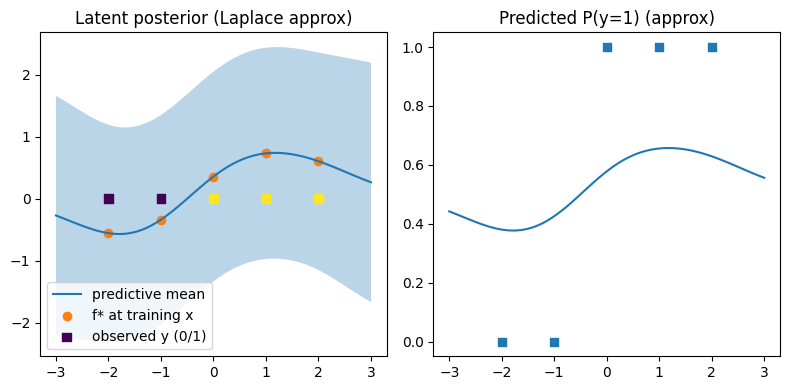

{'X': array([-2., -1.,  0.,  1.,  2.]),
 'y': array([0, 0, 1, 1, 1]),
 'f_star': array([-0.55706839, -0.33908365,  0.35559507,  0.72948368,  0.60217395]),
 'S': array([[ 0.76335926,  0.39677275,  0.04353665, -0.00834139, -0.0009048 ],
        [ 0.39677275,  0.71264959,  0.38908314,  0.0449316 , -0.00779991],
        [ 0.04353665,  0.38908314,  0.7141875 ,  0.3953404 ,  0.04739979],
        [-0.00834139,  0.0449316 ,  0.3953404 ,  0.72519948,  0.40443724],
        [-0.0009048 , -0.00779991,  0.04739979,  0.40443724,  0.76884086]]),
 'Xtest': array([-3.  , -2.95, -2.9 , -2.85, -2.8 , -2.75, -2.7 , -2.65, -2.6 ,
        -2.55, -2.5 , -2.45, -2.4 , -2.35, -2.3 , -2.25, -2.2 , -2.15,
        -2.1 , -2.05, -2.  , -1.95, -1.9 , -1.85, -1.8 , -1.75, -1.7 ,
        -1.65, -1.6 , -1.55, -1.5 , -1.45, -1.4 , -1.35, -1.3 , -1.25,
        -1.2 , -1.15, -1.1 , -1.05, -1.  , -0.95, -0.9 , -0.85, -0.8 ,
        -0.75, -0.7 , -0.65, -0.6 , -0.55, -0.5 , -0.45, -0.4 , -0.35,
        -0.3 , -0.25, -0.2 ,

In [106]:
# Laplace approximation for GP posterior with a non-Gaussian (logistic) likelihood.
# This code is visible to the user and prints numeric results and a small plot.
import numpy as np
from scipy.linalg import cholesky, cho_solve, solve
import matplotlib.pyplot as plt

# --- Problem setup (numeric) ---
# Input locations (1D) and observed binary labels y (0/1)
X = np.array([-2., -1., 0., 1., 2.])
y = np.array([0, 0, 1, 1, 1])   # binary observations

# RBF kernel (squared exponential)
def rbf(x1, x2, lengthscale=1.0, variance=1.0):
    d2 = (x1[:,None] - x2[None,:])**2
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

lengthscale = 1.0
variance = 1.0
K = rbf(X, X, lengthscale, variance) + 1e-6*np.eye(len(X))  # jitter for stability
n = len(X)

# Logistic (sigmoid) likelihood functions
def sigmoid(a):
    return 1.0 / (1.0 + np.exp(-a))

def log_lik_and_derivs(f):
    pi = sigmoid(f)
    # log likelihood (sum over data)
    loglik = np.sum(y*np.log(pi + 1e-12) + (1-y)*np.log(1-pi + 1e-12))
    # gradient wrt f: y - pi
    grad = y - pi
    # negative Hessian diagonal (for Laplace): W = diag(pi*(1-pi))
    W = pi * (1 - pi)
    return loglik, grad, W

# --- Find MAP f* via Newton's method ---
f = np.zeros(n)   # initial guess
Kinv = np.linalg.inv(K)  # small n, direct inverse acceptable for clarity

max_iter = 50
tol = 1e-6
for i in range(max_iter):
    loglik, grad, Wdiag = log_lik_and_derivs(f)
    W = np.diag(Wdiag)
    # gradient of log posterior: grad_logp = grad - K^{-1} f
    grad_logp = grad - Kinv.dot(f)
    # Hessian of negative log posterior: H = K^{-1} + W
    H = Kinv + W
    # Newton step: solve H delta = grad_logp  -> delta = H^{-1} grad_logp
    delta = solve(H, grad_logp, assume_a='pos')
    f_new = f + delta
    if np.max(np.abs(f_new - f)) < tol:
        f = f_new
        break
    f = f_new

# Posterior approx: Gaussian N(f*, S) with S = (K^{-1} + W)^-1
loglik, grad, Wdiag = log_lik_and_derivs(f)
W = np.diag(Wdiag)
S = np.linalg.inv(Kinv + W)   # posterior covariance

# Print MAP and posterior covariance diagonal (uncertainty)
print("Converged in {} iterations".format(i+1))
print("Posterior mean (f*):\n", np.round(f, 4))
print("Posterior std (diag(S)):\n", np.round(np.sqrt(np.diag(S)), 4))
print("\nPosterior covariance matrix S:\n", np.round(S, 5))

# --- Predictive at new points ---
Xtest = np.linspace(-3, 3, 121)
K_s = rbf(X, Xtest, lengthscale, variance)   # k_* (n x m)
K_ss = rbf(Xtest, Xtest, lengthscale, variance)

# Predictive mean for latent f_*: m_* = k_*^T K^{-1} f*
m_star = K_s.T.dot(Kinv).dot(f)

# Predictive variance: v_* = k** - k_*^T (K^{-1} - K^{-1} S K^{-1}) k_*
A = Kinv - Kinv.dot(S).dot(Kinv)   # this matrix appears in predictive var formula
v_star = np.maximum(np.diag(K_ss) - np.sum(K_s * (A.dot(K_s)), axis=0), 1e-12)

# Convert latent predictive mean to predictive class probability via probit/approx
# For logistic likelihood one common approximation to predictive prob is using:
# p(y=1|x) ≈ sigma( m_* / sqrt(1 + pi * v_*/8) )  (a logistic-Gaussian approximation)
p_approx = sigmoid(m_star / np.sqrt(1.0 + np.pi * v_star / 8.0))

# Plot posterior mean and uncertainty and predictive probabilities
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Latent posterior (Laplace approx)")
plt.plot(Xtest, m_star, label='predictive mean')
plt.fill_between(Xtest, m_star - 2*np.sqrt(v_star), m_star + 2*np.sqrt(v_star), alpha=0.3)
plt.scatter(X, f, marker='o', label='f* at training x')
plt.scatter(X, np.zeros_like(X), c=y, marker='s', label='observed y (0/1)')
plt.legend(loc='lower left')

plt.subplot(1,2,2)
plt.title("Predicted P(y=1) (approx)")
plt.plot(Xtest, p_approx)
plt.scatter(X, y, marker='s')
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

# Save numeric results to print summary as well
summary = {
    'X': X, 'y': y, 'f_star': f, 'S': S,
    'Xtest': Xtest, 'm_star': m_star, 'v_star': v_star, 'p_approx': p_approx
}
summary



Acceptance rate: 0.38485
Posterior mean estimate:
 [-0.59557615 -0.35364477  0.34230792  0.72002146  0.61626067]
Posterior covariance estimate:
 [[ 0.68102654  0.34376876  0.021144   -0.03018102  0.00389491]
 [ 0.34376876  0.63576407  0.32452607  0.00962756  0.00586369]
 [ 0.021144    0.32452607  0.61784791  0.3289943   0.04895055]
 [-0.03018102  0.00962756  0.3289943   0.68142197  0.38245496]
 [ 0.00389491  0.00586369  0.04895055  0.38245496  0.72843348]]


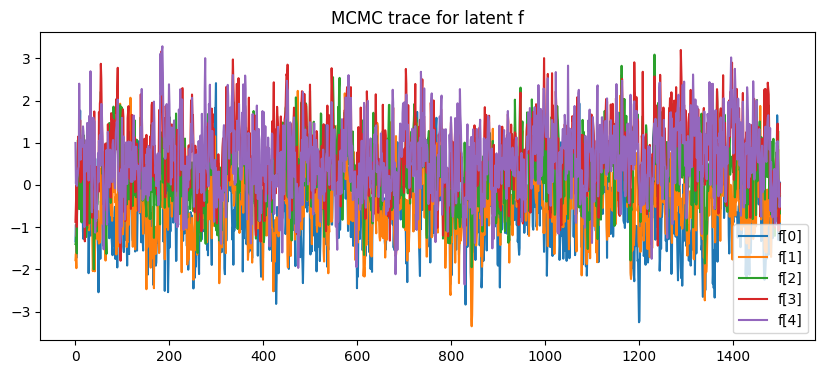

/tmp/ipykernel_9647/2801678811.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(samples, labels=[f"x={xi}" for xi in X])


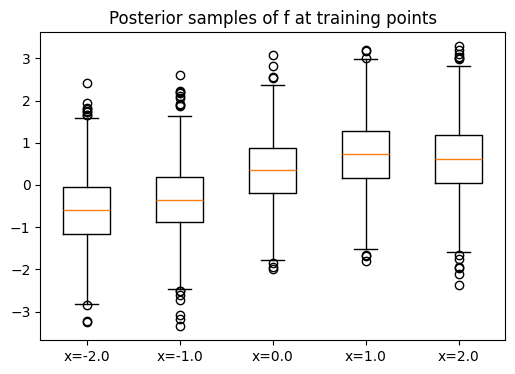

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import slogdet, inv

# -----------------------------
# 1. DATA
# -----------------------------
X = np.array([-2., -1., 0., 1., 2.])
y = np.array([0, 0, 1, 1, 1])
n = len(X)

# -----------------------------
# 2. RBF KERNEL + PRIOR
# -----------------------------
def rbf(x1, x2, lengthscale=1.0, variance=1.0):
    d2 = (x1[:, None] - x2[None, :]) ** 2
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

K = rbf(X, X, lengthscale=1.0, variance=1.0) + 1e-8*np.eye(n)
Kinv = inv(K)
sign, logdetK = slogdet(K)

# -----------------------------
# 3. LOGISTIC LIKELIHOOD
# -----------------------------
def sigmoid(f):
    return 1.0 / (1.0 + np.exp(-f))

def log_prior(f):
    return -0.5 * f @ Kinv @ f - 0.5 * logdetK - 0.5*n*np.log(2*np.pi)

def log_likelihood(f):
    p = sigmoid(f)
    return np.sum(y*np.log(p + 1e-12) + (1-y)*np.log(1-p + 1e-12))

def log_posterior(f):
    return log_prior(f) + log_likelihood(f)

# -----------------------------
# 4. METROPOLIS–HASTINGS MCMC
# -----------------------------
n_iter = 20000
burn = 5000
thin = 10

prop_scale = 0.5    # tune this if acceptance too high/low

samples = []
f = np.zeros(n)      # initial point
lp = log_posterior(f)
accepts = 0

for t in range(n_iter):
    proposal = f + prop_scale * np.random.randn(n)
    lp_prop = log_posterior(proposal)

    if np.log(np.random.rand()) < lp_prop - lp:
        f = proposal
        lp = lp_prop
        accepts += 1
    
    if t >= burn and ((t - burn) % thin == 0):
        samples.append(f.copy())

samples = np.array(samples)

print("Acceptance rate:", accepts / n_iter)
print("Posterior mean estimate:\n", samples.mean(axis=0))
print("Posterior covariance estimate:\n", np.cov(samples.T))

# -----------------------------
# 5. OPTIONAL PLOTS
# -----------------------------
plt.figure(figsize=(10,4))
for i in range(n):
    plt.plot(samples[:, i], label=f"f[{i}]")
plt.title("MCMC trace for latent f")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(samples, labels=[f"x={xi}" for xi in X])
plt.title("Posterior samples of f at training points")
plt.show()


In [3]:
# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt


config.update("jax_enable_x64", True)


with install_import_hook("gpjax", "beartype.beartype"):
    import gpjax as gpx


key = jr.key(123)


cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

/dolfinx-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
n = 100
noise = 0.3

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x)
signal = f(x)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

xtest = jnp.linspace(-3.5, 3.5, 500).reshape(-1, 1)
ytest = f(xtest)

In [5]:
kernel = gpx.kernels.RBF()  # 1-dimensional input
meanf = gpx.mean_functions.Zero()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)

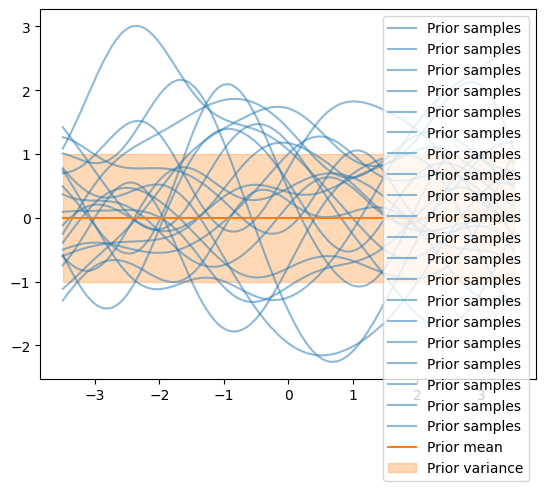

In [7]:
prior_dist = prior.predict(xtest, return_covariance_type="dense")

prior_mean = prior_dist.mean 
prior_std = prior_dist.variance 
samples = prior_dist.sample(key=key, sample_shape=(20,))

fig, ax = plt.subplots() 
ax.plot(xtest, samples.T, alpha=0.5, color=cols[0], label="Prior samples") 
ax.plot(xtest, prior_mean, color=cols[1], label="Prior mean") 
ax.fill_between( xtest.flatten(), prior_mean - prior_std, prior_mean + prior_std, alpha=0.3, color=cols[1], label="Prior variance", ) 
ax.legend(loc="best") 